In [1]:
import torch
import matplotlib.pyplot as plt

### Creating a classification dataset

In [2]:
from sklearn.datasets import make_circles

# create 1000 samples
n_samples = 1000

# create circles dataset
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
# check out the first 5 samples of X and y
print(f"First 5 samples of X: \n{X[:5]}")
print(f"First 5 samples of y: \n{y[:5]}")

First 5 samples of X: 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: 
[1 1 1 1 0]


In [5]:
# making a dataframe of circles
import pandas as pd

df = pd.DataFrame({"X0": X[:, 0], 
                   "X1": X[:, 1], 
                   "label": y})

df.head()

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


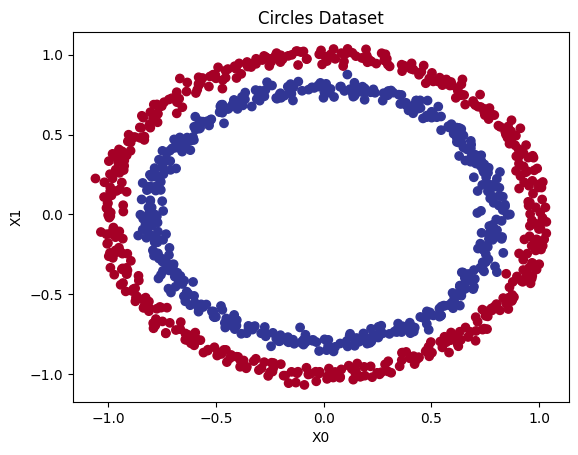

In [6]:
# plotting a scatter plot of the circles
plt.scatter(X[:, 0], 
            X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu)
plt.xlabel("X0")
plt.ylabel("X1")
plt.title("Circles Dataset")
plt.show()

### Checking input and output shapes

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

### Converting the numpy arrays to tensors

In [8]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
X.dtype, y.dtype

(torch.float32, torch.float32)

### Splitting the data in train and test sets

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

In [11]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 800
Testing samples: 200


### Building a Model

In [12]:
import torch
from torch import nn

# create a device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [13]:
# 1. construct a model that subclasses nn.Module
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create two layers capable of handling the shape of the data
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
    
    # 3. Create a forward method which shows the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2  -> output

# 4. Instantiate a instance of the model class
model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
next(model_0.parameters()).device # to check if the model's parameters are on the set target device or not

device(type='cuda', index=0)

In [15]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.5795, -0.1185],
                      [ 0.4806,  0.4346],
                      [ 0.2177, -0.2641],
                      [ 0.0619,  0.5232],
                      [ 0.6459, -0.0610]], device='cuda:0')),
             ('0.bias',
              tensor([-0.1015, -0.2147, -0.1297, -0.4162, -0.6395], device='cuda:0')),
             ('1.weight',
              tensor([[-0.4344,  0.3068,  0.2429, -0.4393,  0.1602]], device='cuda:0')),
             ('1.bias', tensor([0.1875], device='cuda:0'))])

In [17]:
# making predictions without training
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))

print(f"Length of predictions : {len(untrained_preds)}, Shape : {untrained_preds.shape}")
print(f"Length of test samples : {len(X_test)}, Shape : {X_test.shape}")
print(f"First 10 predictions :\n{untrained_preds[:10]}")
print(f"First 10 labels :\n{y_test[:10]}")

Length of predictions : 200, Shape : torch.Size([200, 1])
Length of test samples : 200, Shape : torch.Size([200, 2])
First 10 predictions :
tensor([[-0.0648],
        [ 0.1085],
        [-0.1192],
        [-0.0511],
        [ 0.5157],
        [ 0.6166],
        [ 0.6015],
        [ 0.7221],
        [-0.1459],
        [ 0.1272]], device='cuda:0')
First 10 labels :
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [18]:
# setup a loss function and an optimizer
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [19]:
def accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    
    acc = (correct / len(y_pred)) * 100
    
    return acc

In [20]:
# checking the first 5 outputs of the forward pass
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))   
y_logits[:5], y_logits.shape

(tensor([[-0.0648],
         [ 0.1085],
         [-0.1192],
         [-0.0511],
         [ 0.5157]], device='cuda:0'),
 torch.Size([200, 1]))

In [21]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [22]:
# use sigmoid activation
y_pred_probs = torch.sigmoid(y_logits)
torch.round(y_pred_probs[:5])

tensor([[0.],
        [1.],
        [0.],
        [0.],
        [1.]], device='cuda:0')

In [23]:
y_pred = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))))

print(y_pred.shape, y_pred_labels.shape)
print(torch.eq(y_pred.squeeze()[:5], y_pred_labels.squeeze()[:5]))

print(y_pred.squeeze()[:5])

torch.Size([200, 1]) torch.Size([200, 1])
tensor([True, True, True, True, True], device='cuda:0')
tensor([0., 1., 0., 0., 1.], device='cuda:0')


### Building Training and Testing Loop

In [24]:
y_train.shape, y_logits.shape

(torch.Size([800]), torch.Size([200, 1]))

In [25]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# put the data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# build training and testing loops
for epoch in range(epochs):
    # TRAINING
    model_0.train()
    
    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels
    
    # 2. Calculate the loss
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as inputs
    #                y_train)
    loss = loss_fn(y_logits, y_train) # nn.BCEWithLogitsLoss expects raw logits as inputs
    acc = accuracy(y_true=y_train, y_pred=y_pred)
    
    # 3. optimizer zero grad
    optimizer.zero_grad()
    
    # 4. loss backward
    loss.backward()
    
    # 5. optimizer step
    optimizer.step()
    
    # TESTING
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # 2. Test loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy(y_true=y_test,
                            y_pred=test_pred)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.2f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71329 | Acc: 52.12% | Test Loss: 0.72 | Test acc: 52.50%
Epoch: 10 | Loss: 0.71253 | Acc: 52.12% | Test Loss: 0.71 | Test acc: 53.00%
Epoch: 20 | Loss: 0.71182 | Acc: 52.00% | Test Loss: 0.71 | Test acc: 53.00%
Epoch: 30 | Loss: 0.71115 | Acc: 51.62% | Test Loss: 0.71 | Test acc: 52.00%
Epoch: 40 | Loss: 0.71052 | Acc: 51.38% | Test Loss: 0.71 | Test acc: 51.50%
Epoch: 50 | Loss: 0.70993 | Acc: 51.50% | Test Loss: 0.71 | Test acc: 51.50%
Epoch: 60 | Loss: 0.70938 | Acc: 51.25% | Test Loss: 0.71 | Test acc: 51.50%
Epoch: 70 | Loss: 0.70886 | Acc: 51.25% | Test Loss: 0.71 | Test acc: 51.50%
Epoch: 80 | Loss: 0.70836 | Acc: 51.00% | Test Loss: 0.71 | Test acc: 51.50%
Epoch: 90 | Loss: 0.70789 | Acc: 50.75% | Test Loss: 0.71 | Test acc: 52.00%
Epoch: 100 | Loss: 0.70745 | Acc: 50.88% | Test Loss: 0.71 | Test acc: 52.00%
Epoch: 110 | Loss: 0.70703 | Acc: 50.75% | Test Loss: 0.71 | Test acc: 51.50%
Epoch: 120 | Loss: 0.70663 | Acc: 50.75% | Test Loss: 0.71 | Test acc: 51.0

### Visualizing the predictions

c:\Users\DHYEY DESAI\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


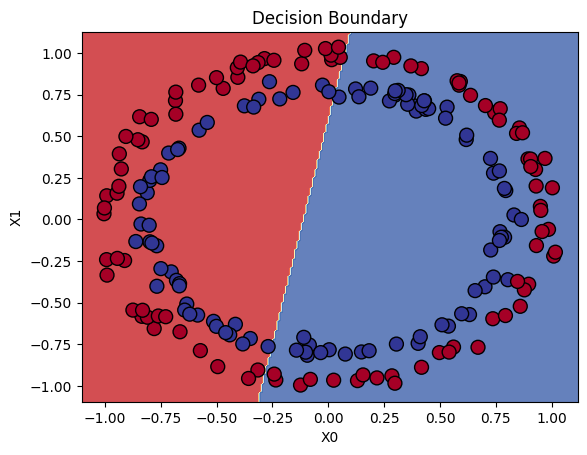

In [26]:
# make predictions and make them visual by plotting decision boundary by showing a background color for each class
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    h = 0.01
    
    # Generate a grid of points with distance h between them
    xx, yy = torch.meshgrid(torch.arange(x_min, x_max, h),
                            torch.arange(y_min, y_max, h))
    
    # Flatten the grid so we can feed it to our model
    grid = torch.cat((xx.reshape(-1, 1), yy.reshape(-1, 1)), dim=1).to(device)
    
    # Make predictions on the grid
    with torch.inference_mode():
        pred_logits = model(grid)
        pred_probs = torch.sigmoid(pred_logits)
        pred_labels = torch.round(pred_probs).cpu().numpy().reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.contourf(xx.cpu(), yy.cpu(), pred_labels, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), edgecolors='k', marker='o', s=100, cmap=plt.cm.RdYlBu)
    plt.xlabel("X0")
    plt.ylabel("X1")
    plt.title("Decision Boundary")
    plt.show()
    
plot_decision_boundary(model=model_0, X=X_test, y=y_test)


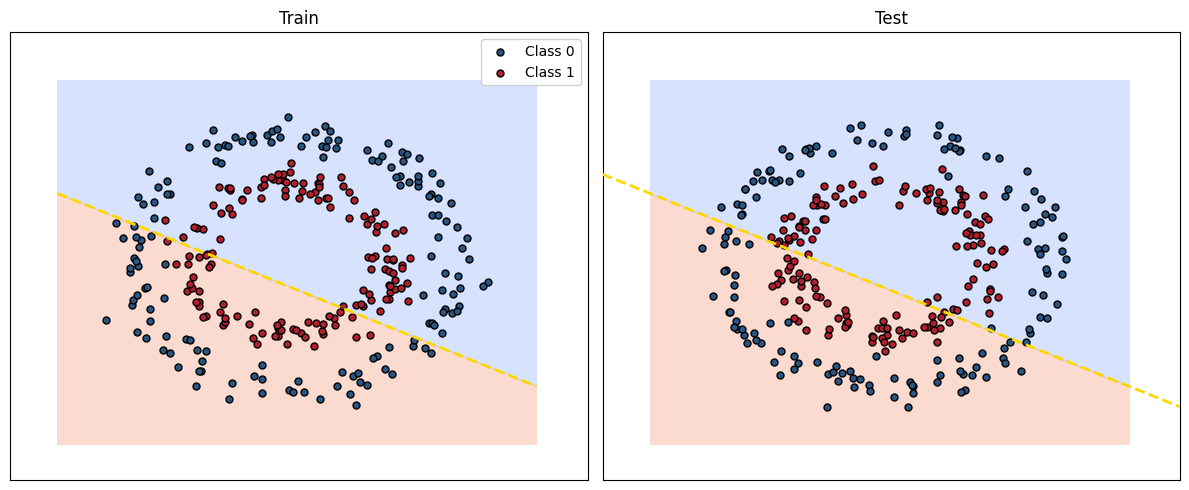

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def plot_decision_regions(ax, model, X, cmap_bg='coolwarm', resolution=200):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg, levels=np.arange(-0.5, 2), zorder=0)

def make_and_plot(seed=0):
    X, y = make_circles(n_samples=600, factor=0.6, noise=0.08, random_state=seed)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(solver='lbfgs', random_state=seed)
    clf.fit(X_train_s, y_train)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax, Xs, ys, title in zip(axes, (X_train_s, X_test_s), (y_train, y_test), ("Train", "Test")):
        plot_decision_regions(ax, clf, np.vstack([X_train_s, X_test_s]))
        ax.scatter(Xs[ys == 0, 0], Xs[ys == 0, 1], c='#2a5683', s=25, edgecolor='k', label='Class 0', zorder=2)
        ax.scatter(Xs[ys == 1, 0], Xs[ys == 1, 1], c='#b21f2d', s=25, edgecolor='k', label='Class 1', zorder=2)

        coef = clf.coef_[0]
        intercept = clf.intercept_[0]
        if abs(coef[1]) > 1e-6:
            xs = np.array(ax.get_xlim())
            ys_line = -(coef[0] / coef[1]) * xs - intercept / coef[1]
            ax.plot(xs, ys_line, color='gold', lw=2, linestyle='--', zorder=3)

        ax.set_title(title)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_xticks([])
        ax.set_yticks([])

    axes[0].legend(loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

make_and_plot()


### Improving the model

In [28]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
    
    def forward(self, x):
        # x = self.layer_1(x)
        # x = self.layer_2(x)
        # x = self.layer_3(x)
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV2().to(device)
model_1

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [29]:
# create a loss function and an optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

# training loop
epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put the data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range(epochs):
    # put model in training mode
    model_1.train()
    
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels
    
    # 2. Calculate the loss
    loss = loss_fn(y_logits, y_train) # nn.BCEWithLogitsLoss expects raw logits as inputs
    acc = accuracy(y_true=y_train, y_pred=y_pred)
    
    # 3. optimizer zero grad
    optimizer.zero_grad()
    
    # 4. loss backward
    loss.backward()
    
    # 5. optimizer step
    optimizer.step()
    
    # TESTING
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # 2. Test loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy(y_true=y_test,
                            y_pred=test_pred)
        
    # print out what's happening every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.2f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.69396 | Train Acc: 50.88% | Test Loss: 0.69 | Test acc: 51.00%
Epoch: 100 | Train Loss: 0.69305 | Train Acc: 50.38% | Test Loss: 0.69 | Test acc: 48.00%
Epoch: 200 | Train Loss: 0.69299 | Train Acc: 51.12% | Test Loss: 0.69 | Test acc: 46.00%
Epoch: 300 | Train Loss: 0.69298 | Train Acc: 51.62% | Test Loss: 0.69 | Test acc: 45.00%
Epoch: 400 | Train Loss: 0.69298 | Train Acc: 51.12% | Test Loss: 0.69 | Test acc: 46.00%
Epoch: 500 | Train Loss: 0.69298 | Train Acc: 51.00% | Test Loss: 0.69 | Test acc: 46.00%
Epoch: 600 | Train Loss: 0.69298 | Train Acc: 51.00% | Test Loss: 0.69 | Test acc: 46.00%
Epoch: 700 | Train Loss: 0.69298 | Train Acc: 51.00% | Test Loss: 0.69 | Test acc: 46.00%
Epoch: 800 | Train Loss: 0.69298 | Train Acc: 51.00% | Test Loss: 0.69 | Test acc: 46.00%
Epoch: 900 | Train Loss: 0.69298 | Train Acc: 51.00% | Test Loss: 0.69 | Test acc: 46.00%


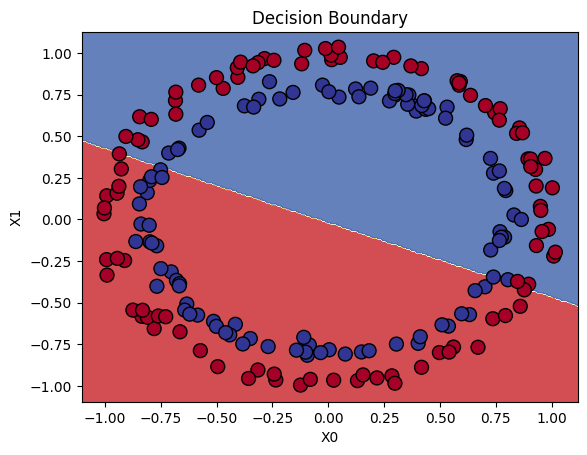

In [30]:
# plotting decision boundary of model_1
plot_decision_boundary(model=model_1, X=X_test, y=y_test)

## Trying to fit `model_1` on a linear data

In [31]:
# fitting model_1 on the linear data
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.01
X_reg = torch.arange(start, end, step).unsqueeze(dim=1)
y_reg = weight * X_reg + bias
print(f"X: {X_reg[:10]} \n y: {y_reg[:10]}")

X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]]) 
 y: tensor([[0.3000],
        [0.3070],
        [0.3140],
        [0.3210],
        [0.3280],
        [0.3350],
        [0.3420],
        [0.3490],
        [0.3560],
        [0.3630]])


In [32]:
train_set = int(0.8 * len(X_reg))
X_train_reg, y_train_reg = X_reg[:train_set], y_reg[:train_set]
X_test_reg, y_test_reg = X_reg[train_set:], y_reg[train_set:]

len(X_train_reg), len(y_train_reg), len(X_test_reg), len(y_test_reg)

(80, 80, 20, 20)

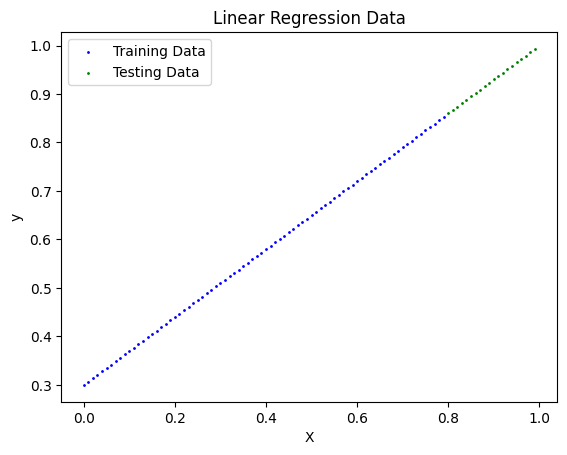

In [33]:
# plotting the regression train and test data
# convert tensors to numpy arrays by first moving them to cpu and then using .numpy() method

X_train_reg_np = X_train_reg.cpu().numpy()
y_train_reg_np = y_train_reg.cpu().numpy()
X_test_reg_np = X_test_reg.cpu().numpy()
y_test_reg_np = y_test_reg.cpu().numpy()
plt.scatter(X_train_reg_np, y_train_reg_np, c='blue', s=1, label='Training Data')
plt.scatter(X_test_reg_np, y_test_reg_np, c='green', s=1, label='Testing Data')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Data")
plt.legend()
plt.show()

### Adjusting `model_1` to fit a straight line

In [34]:
model_linear = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

# choose a loss function and an optimizer
loss_fn_linear = nn.L1Loss()
optimizer_linear = torch.optim.SGD(model_linear.parameters(), lr=0.001)

# ensure the new linear data is on the correct device
X_train_reg, y_train_reg = X_train_reg.to(device), y_train_reg.to(device)
X_test_reg, y_test_reg = X_test_reg.to(device), y_test_reg.to(device)

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
for epoch in range(epochs):
    model_linear.train()
    y_pred = model_linear(X_train_reg)
    loss = loss_fn_linear(y_pred, y_train_reg)

    optimizer_linear.zero_grad()
    loss.backward()
    optimizer_linear.step()

    model_linear.eval()
    with torch.inference_mode():
        test_pred = model_linear(X_test_reg)
        test_loss = loss_fn_linear(test_pred, y_test_reg)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.75986 | Test Loss: 0.94965
Epoch: 100 | Train Loss: 0.40272 | Test Loss: 0.54029
Epoch: 200 | Train Loss: 0.05876 | Test Loss: 0.13480
Epoch: 300 | Train Loss: 0.01461 | Test Loss: 0.03342
Epoch: 400 | Train Loss: 0.00308 | Test Loss: 0.00008
Epoch: 500 | Train Loss: 0.00309 | Test Loss: 0.00012
Epoch: 600 | Train Loss: 0.00309 | Test Loss: 0.00018
Epoch: 700 | Train Loss: 0.00299 | Test Loss: 0.00011
Epoch: 800 | Train Loss: 0.00299 | Test Loss: 0.00016
Epoch: 900 | Train Loss: 0.00289 | Test Loss: 0.00011


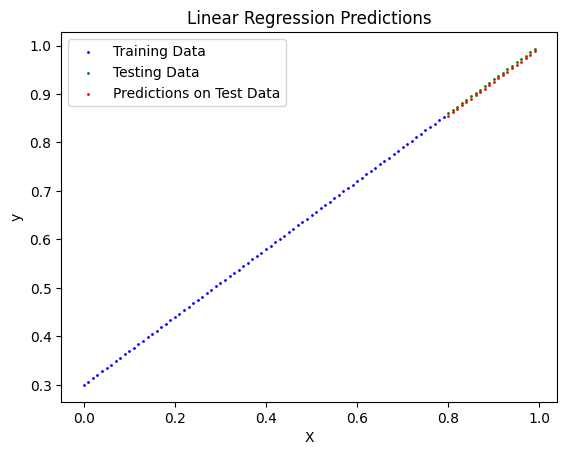

In [35]:
# plotting the predictions on test data along with train and test data
model_linear.eval()
with torch.inference_mode():
    y_pred_test = model_linear(X_test_reg)
y_pred_test_np = y_pred_test.cpu().numpy()
plt.scatter(X_train_reg_np, y_train_reg_np, c='blue', s=1, label='Training Data')
plt.scatter(X_test_reg_np, y_test_reg_np, c='green', s=1, label='Testing Data')
plt.scatter(X_test_reg_np, y_pred_test_np, c='red', s=1, label='Predictions on Test Data')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Predictions")
plt.legend()
plt.show()

## Introducing ReLU function in the network

In [36]:
from torch import nn

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [37]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(), lr=0.001)

In [38]:
# building a training loop for model_3
epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put the data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # put model in training mode
    model_3.train()
    
    # 1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels
    
    # 2. Calculate the loss
    loss = loss_fn(y_logits, y_train) # nn.BCEWithLogitsLoss expects raw logits as inputs
    acc = accuracy(y_true=y_train, y_pred=y_pred)
    
    # 3. optimizer zero grad
    optimizer.zero_grad()
    
    # 4. loss backward
    loss.backward()
    
    # 5. optimizer step
    optimizer.step()
    
    # TESTING
    model_3.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # 2. Test loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy(y_true=y_test,
                            y_pred=test_pred)
        
    # print out what's happening every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.2f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.69295 | Train Acc: 50.00% | Test Loss: 0.69 | Test Acc: 50.00%
Epoch: 100 | Train Loss: 0.68481 | Train Acc: 52.88% | Test Loss: 0.68 | Test Acc: 57.00%
Epoch: 200 | Train Loss: 0.66289 | Train Acc: 64.50% | Test Loss: 0.66 | Test Acc: 65.00%
Epoch: 300 | Train Loss: 0.60675 | Train Acc: 78.38% | Test Loss: 0.61 | Test Acc: 76.50%
Epoch: 400 | Train Loss: 0.50024 | Train Acc: 95.12% | Test Loss: 0.51 | Test Acc: 94.00%
Epoch: 500 | Train Loss: 0.38035 | Train Acc: 98.88% | Test Loss: 0.41 | Test Acc: 98.50%
Epoch: 600 | Train Loss: 0.26408 | Train Acc: 99.75% | Test Loss: 0.29 | Test Acc: 99.50%
Epoch: 700 | Train Loss: 0.18558 | Train Acc: 99.62% | Test Loss: 0.22 | Test Acc: 99.50%
Epoch: 800 | Train Loss: 0.13569 | Train Acc: 99.75% | Test Loss: 0.17 | Test Acc: 99.00%
Epoch: 900 | Train Loss: 0.10229 | Train Acc: 99.88% | Test Loss: 0.13 | Test Acc: 99.50%


In [39]:
# plotting the predictions of the regression model
model_linear.eval()
with torch.inference_mode():
    y_pred_test = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_pred_test[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

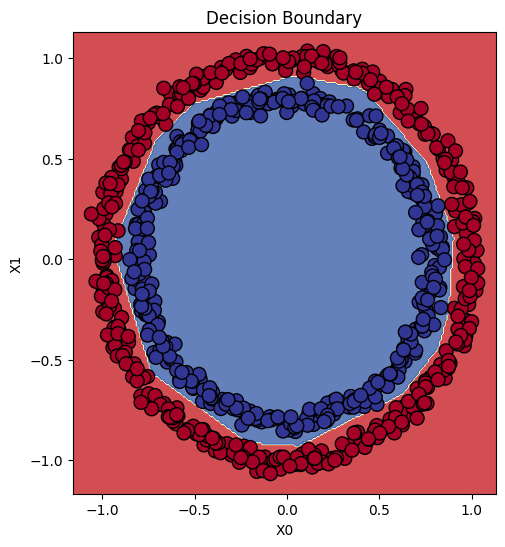

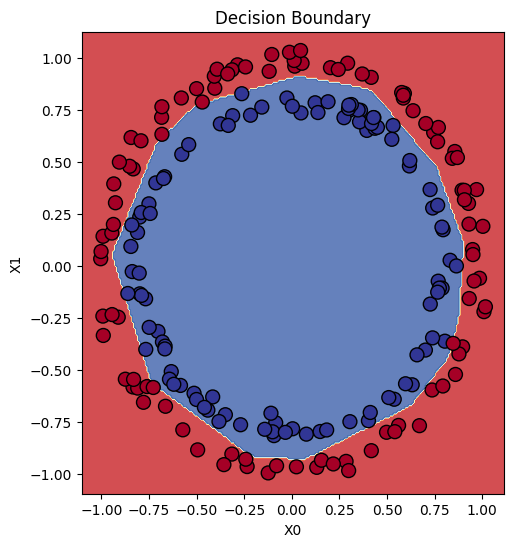

In [40]:
# plotting the predictions of the regression model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model=model_3, X=X_train, y=y_train)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model=model_3, X=X_test, y=y_test)